In [95]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [96]:
fraud = pd.read_csv("../data/raw/Fraud_Data.csv")

country = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [97]:
print("Fraud Shape:", fraud.shape)
print("Country Shape:", country.shape)

Fraud Shape: (151112, 11)
Country Shape: (138846, 3)


In [98]:
fraud["signup_time"] = pd.to_datetime(
    fraud["signup_time"]
)

fraud["purchase_time"] = pd.to_datetime(
    fraud["purchase_time"]
)

In [99]:
fraud["time_since_signup"] = (
    fraud["purchase_time"]
    -
    fraud["signup_time"]
).dt.total_seconds() / 3600

In [100]:
fraud["hour_of_day"] = (
    fraud["purchase_time"].dt.hour
)

In [101]:
fraud["day_of_week"] = (
    fraud["purchase_time"].dt.dayofweek
)

In [102]:
fraud["transaction_count"] = (
    fraud.groupby("user_id")["user_id"]
    .transform("count")
)

In [103]:
fraud["transactions_per_device"] = (
    fraud.groupby("device_id")["device_id"]
    .transform("count")
)

In [104]:
fraud[
    [
        "time_since_signup",
        "hour_of_day",
        "day_of_week",
        "transaction_count",
        "transactions_per_device"
    ]
].head()

,time_since_signup,hour_of_day,day_of_week,transaction_count,transactions_per_device
0,1251.856111,2,5,1,1
1,4.984444,1,0,1,1
2,0.000278,18,3,1,12
3,136.690278,13,0,1,1
4,1211.516944,18,2,1,1


In [105]:
country["lower_bound_ip_address"] = (
    country["lower_bound_ip_address"]
    .astype("int64")
)

country["upper_bound_ip_address"] = (
    country["upper_bound_ip_address"]
    .astype("int64")
)

In [106]:
fraud["ip_address"] = (
    fraud["ip_address"]
    .astype("int64")
)

In [107]:
fraud = fraud.sort_values(
    "ip_address"
)

country = country.sort_values(
    "lower_bound_ip_address"
)

In [108]:
fraud = pd.merge_asof(
    fraud,
    country,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [109]:
fraud = fraud[
    fraud["ip_address"]
    <= fraud["upper_bound_ip_address"]
]

In [110]:
fraud.columns.tolist()

['user_id',
 'signup_time',
 'purchase_time',
 'purchase_value',
 'device_id',
 'source',
 'browser',
 'sex',
 'age',
 'ip_address',
 'class',
 'time_since_signup',
 'hour_of_day',
 'day_of_week',
 'transaction_count',
 'transactions_per_device',
 'lower_bound_ip_address',
 'upper_bound_ip_address',
 'country']

In [111]:
fraud["country"].value_counts().head(20)

country
United States                      58049
China                              12038
Japan                               7306
United Kingdom                      4490
Korea Republic of                   4162
Germany                             3646
France                              3161
Canada                              2975
Brazil                              2961
Italy                               1944
Australia                           1844
Netherlands                         1680
Russian Federation                  1616
India                               1310
Taiwan; Republic of China (ROC)     1237
Mexico                              1121
Sweden                              1090
Spain                               1027
South Africa                         838
Switzerland                          785
Name: count, dtype: int64

In [112]:
country_fraud = (
    fraud.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
)

country_fraud.head(10)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

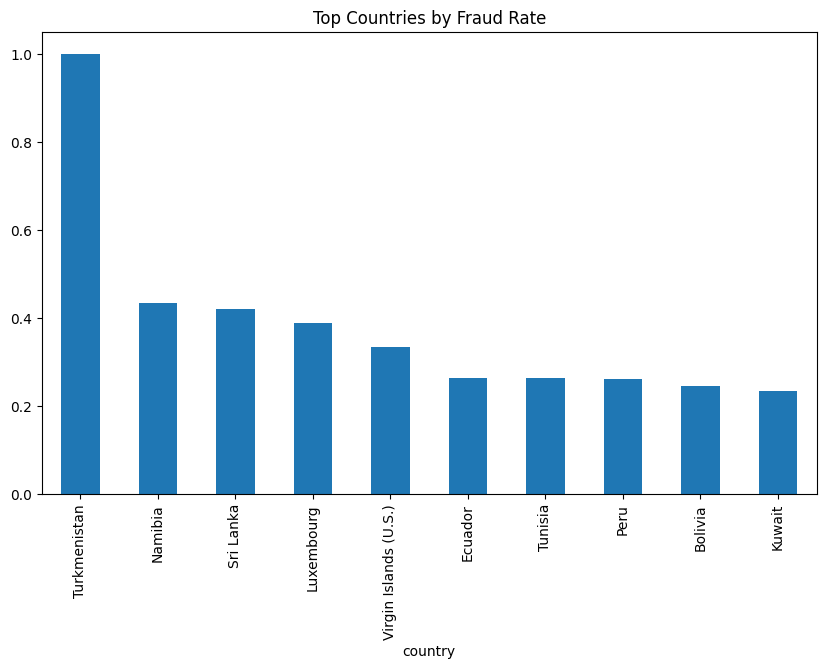

In [113]:
plt.figure(figsize=(10,6))

country_fraud.head(10).plot(
    kind="bar"
)

plt.title("Top Countries by Fraud Rate")

plt.show()

In [114]:
fraud = pd.get_dummies(
    fraud,
    columns=[
        "source",
        "browser",
        "sex",
        "country"
    ],
    drop_first=True
)

In [115]:
fraud.shape

(129146, 202)

In [116]:
scaler = StandardScaler()

columns_to_scale = [
    "purchase_value",
    "age",
    "time_since_signup",
    "transaction_count",
    "transactions_per_device"
]

fraud[columns_to_scale] = (
    scaler.fit_transform(
        fraud[columns_to_scale]
    )
)

In [117]:
fraud[
    columns_to_scale
].describe()

,purchase_value,age,time_since_signup,transaction_count,transactions_per_device
count,1.291460e+05,1.291460e+05,1.291460e+05,129146.0,1.291460e+05
mean,-1.206007e-16,-1.018944e-16,-1.082765e-16,0.0,-4.049366e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,0.0,1.000004e+00
min,-1.524887e+00,-1.756001e+00,-1.574394e+00,0.0,-2.640693e-01
25%,-8.151916e-01,-7.113436e-01,-8.777507e-01,0.0,-2.640693e-01
50%,-1.054965e-01,-1.490527e-02,-6.163021e-04,0.0,-2.640693e-01
75%,6.587905e-01,6.815331e-01,8.679339e-01,0.0,-2.640693e-01
max,6.390943e+00,4.976236e+00,1.738463e+00,0.0,6.890798e+00


In [118]:
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,time_since_signup,hour_of_day,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,0.549607,KIXYSVCHIPQBR,-0.363124,16778864,0,-0.413800,3,...,False,False,False,False,False,False,False,False,False,False
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,-1.197335,PKYOWQKWGJNJI,0.101168,16842045,0,-1.180852,20,...,False,False,False,False,False,False,False,False,False,False
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,0.385831,LVCSXLISZHVUO,-0.479197,16843656,0,-0.936126,23,...,False,False,False,False,False,False,False,False,False,False
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,0.986342,UHAUHNXXUADJE,-0.363124,16938732,0,0.867086,16,...,False,False,False,False,False,False,False,False,False,False
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,0.767974,XPGPMOHIDRMGE,0.449387,16971984,0,1.700633,4,...,False,False,False,False,False,False,False,False,False,False


In [119]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [120]:
fraud.to_csv(
    "../data/processed/fraud_processed.csv",
    index=False
)

In [121]:
os.listdir("../data/processed")

['credit_clean.csv', 'fraud_clean.csv', 'fraud_processed.csv']

In [122]:
print("""
TASK 1 FEATURE ENGINEERING COMPLETE

✓ Time Features
✓ User Features
✓ Device Features
✓ Country Mapping
✓ Encoding
✓ Scaling
✓ Saved Processed Dataset
""")


TASK 1 FEATURE ENGINEERING COMPLETE

✓ Time Features
✓ User Features
✓ Device Features
✓ Country Mapping
✓ Encoding
✓ Scaling
✓ Saved Processed Dataset

